In [1]:
import pandas as pd

meta = pd.read_csv("../data/HAM10000_metadata.csv")
meta.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [2]:
meta['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [3]:
import os

img1 = set(os.listdir("../data/HAM10000_images_part_1"))
img2 = set(os.listdir("../data/HAM10000_images_part_2"))
all_imgs = img1 | img2

meta_imgs = set(meta['image_id'] + ".jpg")

len(meta_imgs - all_imgs)

0

(600, 450)


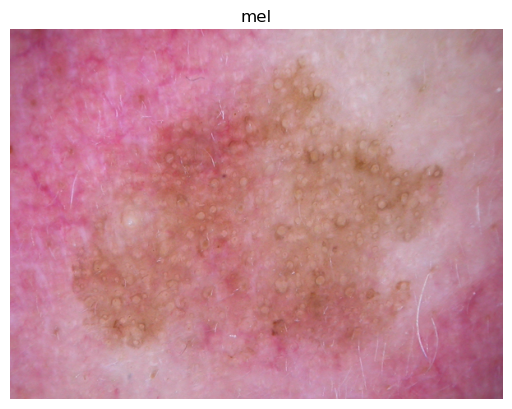

(600, 450)


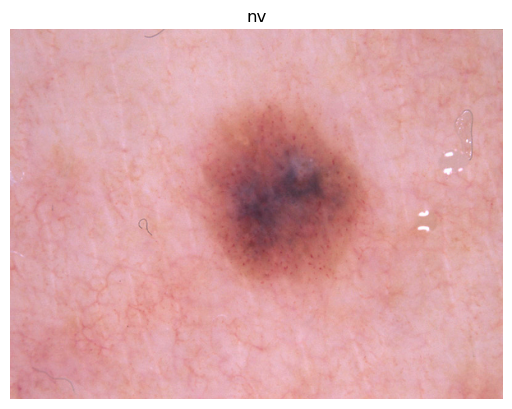

(600, 450)


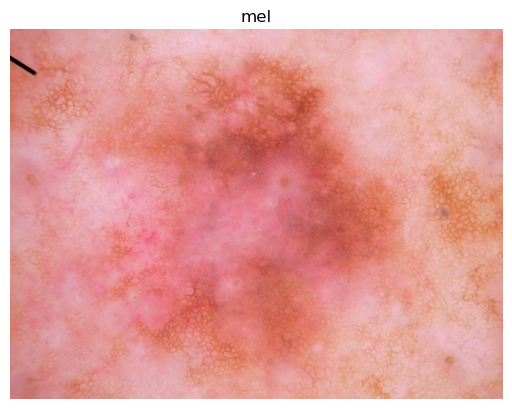

(600, 450)


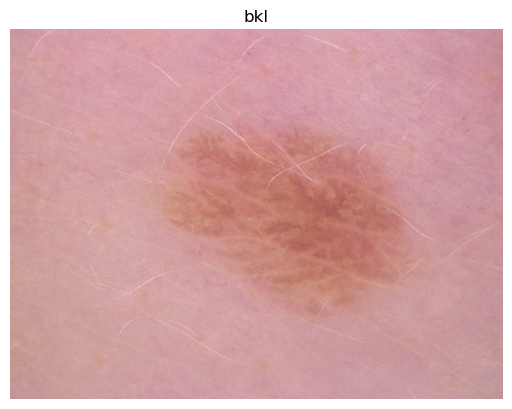

(600, 450)


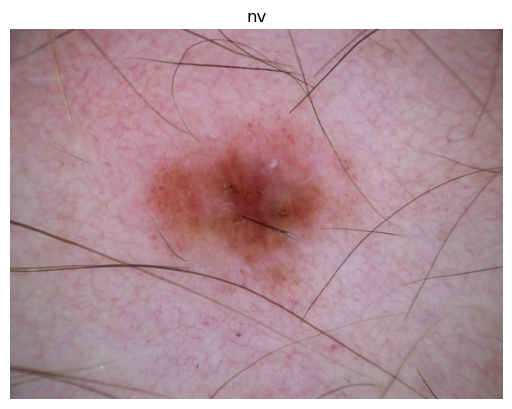

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

sample = meta.sample(5, random_state=42)

for _, row in sample.iterrows():
    img_name = row['image_id'] + ".jpg"
    path = "../data/HAM10000_images_part_1/" + img_name
    if not os.path.exists(path):
        path = "../data/HAM10000_images_part_2/" + img_name
    img = Image.open(path)
    print(img.size)
    img = Image.open(path)
    plt.imshow(img)
    plt.title(row['dx'])
    plt.axis("off")
    plt.show()

In [5]:
meta.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [6]:
meta['dx'].isnull().sum()

np.int64(0)

In [7]:
meta['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

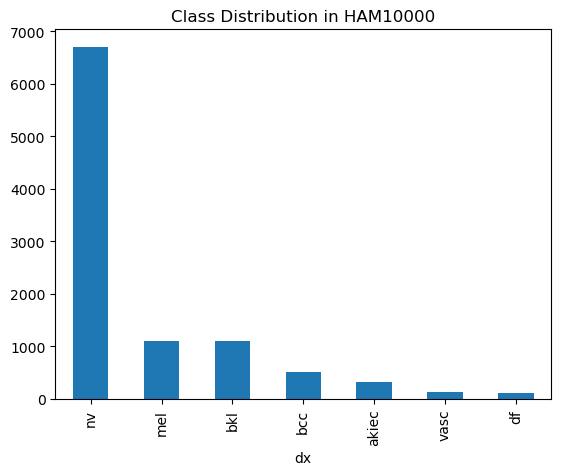

In [8]:
import matplotlib.pyplot as plt

meta['dx'].value_counts().plot(kind='bar')
plt.title("Class Distribution in HAM10000")
plt.show()

In [9]:
from PIL import Image
import os

# take 5 random images
sample = meta.sample(5, random_state=1)

for _, row in sample.iterrows():
    img_name = row['image_id'] + ".jpg"
    path = "../data/HAM10000_images_part_1/" + img_name
    if not os.path.exists(path):
        path = "../data/HAM10000_images_part_2/" + img_name
    
    img = Image.open(path)
    print(img.size)

(600, 450)
(600, 450)
(600, 450)
(600, 450)
(600, 450)


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

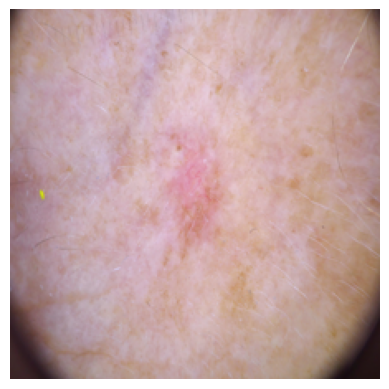

In [10]:
img_resized = img.resize((224, 224))
plt.imshow(img_resized)
plt.axis("off")

In [11]:
def resize_and_center_crop(img, target_size=224):
    # Step 1: get original width and height
    width, height = img.size
    
    # Step 2: find the smaller side
    min_side = min(width, height)
    
    # Step 3: calculate center crop box
    left = (width - min_side) // 2
    top = (height - min_side) // 2
    right = left + min_side
    bottom = top + min_side
    
    # Step 4: crop the center square
    img_cropped = img.crop((left, top, right, bottom))
    
    # Step 5: resize to target size
    img_resized = img_cropped.resize((target_size, target_size))
    
    return img_resized

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

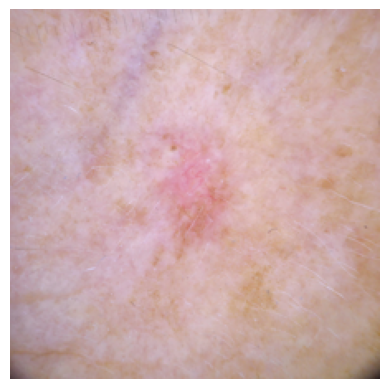

In [12]:
img_safe = resize_and_center_crop(img)
plt.imshow(img_safe)
plt.axis("off")

In [13]:
import os

def get_image_path(image_id):
    img_name = image_id + ".jpg"
    path1 = "../data/HAM10000_images_part_1/" + img_name
    path2 = "../data/HAM10000_images_part_2/" + img_name
    
    if os.path.exists(path1):
        return path1
    else:
        return path2

In [14]:
meta['image_path'] = meta['image_id'].apply(get_image_path)

In [15]:
meta[['image_id', 'dx', 'image_path']].head()

,image_id,dx,image_path
0,ISIC_0027419,bkl,../data/HAM10000_images_part_1/ISIC_0027419.jpg
1,ISIC_0025030,bkl,../data/HAM10000_images_part_1/ISIC_0025030.jpg
2,ISIC_0026769,bkl,../data/HAM10000_images_part_1/ISIC_0026769.jpg
3,ISIC_0025661,bkl,../data/HAM10000_images_part_1/ISIC_0025661.jpg
4,ISIC_0031633,bkl,../data/HAM10000_images_part_2/ISIC_0031633.jpg


In [16]:
from PIL import Image

def load_and_preprocess_image(image_path):
    img = Image.open(image_path)
    img = resize_and_center_crop(img)
    return img

In [17]:
test_row = meta.iloc[0]
test_img = load_and_preprocess_image(test_row['image_path'])

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

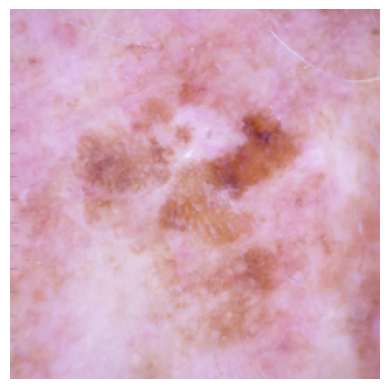

In [18]:
plt.imshow(test_img)
plt.axis("off")

In [19]:
# ----- Core label mapping for HAM10000 -----

label_map = {
    'akiec': 0,
    'bcc': 1,
    'bkl': 2,
    'df': 3,
    'mel': 4,
    'nv': 5,
    'vasc': 6
}

inv_label_map = {v: k for k, v in label_map.items()}

In [20]:
sample_row = meta.iloc[0]

print("Image path:", sample_row['image_path'])
print("Label (dx):", sample_row['dx'])
print("Numeric label:", label_map[sample_row['dx']])

Image path: ../data/HAM10000_images_part_1/ISIC_0027419.jpg
Label (dx): bkl
Numeric label: 2


In [21]:
dataset_pairs = list(
    zip(meta['image_path'], meta['dx'].map(label_map))
)

len(dataset_pairs), dataset_pairs[0]

(10015, ('../data/HAM10000_images_part_1/ISIC_0027419.jpg', 2))

In [22]:
type(dataset_pairs[0][0]), type(dataset_pairs[0][1])

(str, int)

In [23]:
any(p is None or l is None for p, l in dataset_pairs)

False

In [24]:
dataset_pairs[-1]

('../data/HAM10000_images_part_2/ISIC_0032258.jpg', 4)

In [25]:
def get_sample(index):
    return dataset_pairs[index]

In [26]:
get_sample(10)

('../data/HAM10000_images_part_1/ISIC_0025276.jpg', 2)

In [27]:
def get_sample_with_image(index):
    image_path, label = dataset_pairs[index]
    image = load_and_preprocess_image(image_path)
    return image, label

In [28]:
img, lbl = get_sample_with_image(0)

print(type(img))
print(lbl)

<class 'PIL.Image.Image'>
2


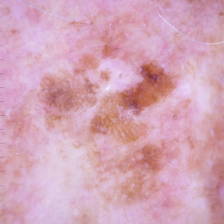

In [29]:
img

In [30]:
class SimpleSkinDataset:
    def __init__(self, dataset_pairs):
        self.dataset_pairs = dataset_pairs

    def __len__(self):
        return len(self.dataset_pairs)

    def __getitem__(self, index):
        image_path, label = self.dataset_pairs[index]
        image = load_and_preprocess_image(image_path)
        return image, label

In [31]:
skin_dataset = SimpleSkinDataset(dataset_pairs)
len(skin_dataset)

10015

In [32]:
img, lbl = skin_dataset[0]

print(type(img))
print(lbl)

<class 'PIL.Image.Image'>
2


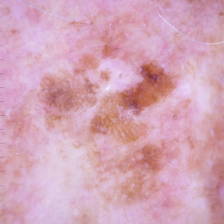

In [33]:
img

In [34]:
from sklearn.model_selection import train_test_split

indices = list(range(len(skin_dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=meta['dx']
)

len(train_idx), len(val_idx)

(8012, 2003)

In [35]:
len(set(train_idx).intersection(set(val_idx)))

0

In [36]:
skin_dataset[train_idx[0]], skin_dataset[val_idx[0]]

((<PIL.Image.Image image mode=RGB size=224x224>, 5),
 (<PIL.Image.Image image mode=RGB size=224x224>, 5))

In [37]:
class DatasetSubset:
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        real_index = self.indices[index]
        return self.dataset[real_index]

In [38]:
train_dataset = DatasetSubset(skin_dataset, train_idx)
val_dataset = DatasetSubset(skin_dataset, val_idx)

len(train_dataset), len(val_dataset)

(8012, 2003)

In [39]:
train_dataset[0], val_dataset[0]

((<PIL.Image.Image image mode=RGB size=224x224>, 5),
 (<PIL.Image.Image image mode=RGB size=224x224>, 5))

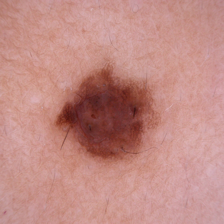

In [40]:
img, lbl = train_dataset[0]
img

In [41]:
from collections import Counter

train_labels = [dataset_pairs[i][1] for i in train_idx]
Counter(train_labels)

Counter({5: 5364, 4: 890, 2: 879, 1: 411, 0: 262, 6: 114, 3: 92})

In [42]:
val_labels = [dataset_pairs[i][1] for i in val_idx]
Counter(val_labels)

Counter({5: 1341, 4: 223, 2: 220, 1: 103, 0: 65, 6: 28, 3: 23})

In [43]:
set(Counter(train_labels).keys()) == set(Counter(val_labels).keys())

True

In [44]:
def get_label(index):
    return dataset_pairs[index][1]

In [45]:
get_label(0)

2

In [46]:
from collections import Counter
Counter(get_label(i) for i in train_idx)

Counter({5: 5364, 4: 890, 2: 879, 1: 411, 0: 262, 6: 114, 3: 92})

In [47]:
class SimpleSkinDataset:
    def __init__(self, dataset_pairs):
        self.dataset_pairs = dataset_pairs

    def __len__(self):
        return len(self.dataset_pairs)

    def get_label(self, index):
        return self.dataset_pairs[index][1]

    def __getitem__(self, index):
        image_path, label = self.dataset_pairs[index]
        image = load_and_preprocess_image(image_path)
        return image, label

In [48]:
skin_dataset = SimpleSkinDataset(dataset_pairs)

In [49]:
skin_dataset.get_label(0)

2

In [50]:
img, lbl = skin_dataset[0]
type(img), lbl

(PIL.Image.Image, 2)

In [51]:
class DatasetSubset:
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def get_label(self, index):
        real_index = self.indices[index]
        return self.dataset.get_label(real_index)

    def __getitem__(self, index):
        real_index = self.indices[index]
        return self.dataset[real_index]

In [52]:
train_dataset = DatasetSubset(skin_dataset, train_idx)
val_dataset = DatasetSubset(skin_dataset, val_idx)

In [53]:
train_dataset.get_label(0), val_dataset.get_label(0)

(5, 5)

In [54]:
print("DATA PIPELINE STATUS")
print("--------------------")
print("Total samples:", len(skin_dataset))
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Classes:", sorted(set(train_dataset.get_label(i) for i in range(len(train_dataset)))))

DATA PIPELINE STATUS
--------------------
Total samples: 10015
Train samples: 8012
Val samples: 2003
Classes: [0, 1, 2, 3, 4, 5, 6]


# NOTE (IMPORTANT)

This notebook is **frozen after data pipeline validation**.

- No further model code
- No training loops
- No confidence logic
- No experiments

All modeling and confidence-related work continues in:
`02_model_basics.ipynb`

In [1]:
import torch
torch.__version__

'2.7.1+cpu'

In [57]:
import torch
from torchvision import transforms

In [58]:
to_tensor = transforms.ToTensor()

In [59]:
img, lbl = skin_dataset[0]
img_tensor = to_tensor(img)

type(img_tensor), img_tensor.shape

(torch.Tensor, torch.Size([3, 224, 224]))

In [60]:
img_tensor.min().item(), img_tensor.max().item()

(0.18431372940540314, 1.0)

In [61]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

In [62]:
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [63]:
img, lbl = skin_dataset[0]
img_tensor = image_transform(img)

type(img_tensor), img_tensor.shape

(torch.Tensor, torch.Size([3, 224, 224]))

In [64]:
img_tensor.min().item(), img_tensor.max().item()

(-1.2128850221633911, 2.640000104904175)

In [65]:
class SimpleSkinDataset:
    def __init__(self, dataset_pairs, transform=None):
        self.dataset_pairs = dataset_pairs
        self.transform = transform

    def __len__(self):
        return len(self.dataset_pairs)

    def get_label(self, index):
        return self.dataset_pairs[index][1]

    def __getitem__(self, index):
        image_path, label = self.dataset_pairs[index]
        image = load_and_preprocess_image(image_path)

        if self.transform:
            image = self.transform(image)

        return image, label

In [66]:
skin_dataset = SimpleSkinDataset(dataset_pairs)

In [67]:
img, lbl = skin_dataset[0]
type(img), lbl

(PIL.Image.Image, 2)

In [68]:
tensor_dataset = SimpleSkinDataset(dataset_pairs, transform=image_transform)

In [69]:
img_tensor, lbl = tensor_dataset[0]
type(img_tensor), img_tensor.shape

(torch.Tensor, torch.Size([3, 224, 224]))

In [70]:
class DatasetSubset:
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def get_label(self, index):
        real_index = self.indices[index]
        return self.dataset.get_label(real_index)

    def __getitem__(self, index):
        real_index = self.indices[index]
        return self.dataset[real_index]

In [71]:
skin_dataset = SimpleSkinDataset(dataset_pairs)
train_dataset = DatasetSubset(skin_dataset, train_idx)
val_dataset = DatasetSubset(skin_dataset, val_idx)

len(train_dataset), len(val_dataset)

(8012, 2003)

In [72]:
tensor_skin_dataset = SimpleSkinDataset(dataset_pairs, transform=image_transform)
tensor_train_dataset = DatasetSubset(tensor_skin_dataset, train_idx)
tensor_val_dataset = DatasetSubset(tensor_skin_dataset, val_idx)

In [73]:
img_tensor, lbl = tensor_train_dataset[0]
type(img_tensor), img_tensor.shape, lbl

(torch.Tensor, torch.Size([3, 224, 224]), 5)

In [74]:
from torch.utils.data import DataLoader

In [75]:
train_loader = DataLoader(
    tensor_train_dataset,
    batch_size=2,
    shuffle=True
)

In [76]:
images, labels = next(iter(train_loader))

type(images), images.shape, labels

(torch.Tensor, torch.Size([2, 3, 224, 224]), tensor([5, 5]))

In [77]:
labels.dtype

torch.int64

In [78]:
for batch_idx, (images, labels) in enumerate(train_loader):
    print("Batch index:", batch_idx)
    print("Images shape:", images.shape)
    print("Labels:", labels)
    break

Batch index: 0
Images shape: torch.Size([2, 3, 224, 224])
Labels: tensor([5, 5])


In [79]:
images.dtype, labels.dtype

(torch.float32, torch.int64)

In [80]:
import torch.nn as nn

class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Linear(8 * 112 * 112, 7)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [81]:
model = TinyCNN()
model

TinyCNN(
  (features): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=100352, out_features=7, bias=True)
)

In [82]:
images, labels = next(iter(train_loader))
outputs = model(images)

outputs.shape

torch.Size([2, 7])

In [83]:
labels.shape

torch.Size([2])